# StatsBomb 360 — Spatial Pressure Visualiser

Two complementary views of a single 360 freeze frame, both drawn on a metric pitch (105 × 68 m, attacking team always left → right):

1. **Voronoi pitch control** (Cells 3–7) — who controls which space, with the touchline treated as a control subject and missing-player uncertainty made explicit.
2. **Pressure-network heterograph** (Cells 8–10) — the typed graph (nodes + weighted edges) that doubles as the GNN input.

Shared conventions: `sb_to_m` rescales StatsBomb 120×80 → 105×68 m; pressure uses `D*_player = 6.4 m`, boundary uses `D*_line = 3.2 m` (see `voronoi_pitch.py` / `pressure_graph.py`).

## How to run

1. Run **Cells 1–5** (config → data → pitch helpers → Voronoi functions).
2. **Cell 5a** prints the first three high-pressure sequences and their event-ID lists; **Cell 6** plots a single frame.
3. **Cell 7** plots a whole sequence (small-multiples + control-area trend).
4. **Cells 8–10** build and draw the heterograph and export the node / edge tables.

## Voronoi figure — element guide

| Element | Meaning |
| --- | --- |
| Blue cells | Attacker control (possession team) |
| Red / orange cells | Defender control (pressing team) |
| **Vivid blue cell** | **Carrier's own control area** (emphasised) |
| **Vivid red cells** | **Presser control** (defenders within `D* = 6.4 m` of carrier) |
| Teal star | Goalkeeper |
| Red gradient along edges | Boundary control band (defensive territory) |
| Grey | Uncontested space (reachable cap on) |
| Hatched | Low-confidence / info-missing region |
| Gold ring | Ball carrier + `D* = 6.4 m` pressure radius |
| Teal dashed arrow | Ball path from the previous frame |
| White dot | Ball / event location |

## Incomplete-data handling

- **Confidence** — every figure prints visible counts (total / attackers / defenders / GK present).
- **Hull mask** — the area outside the players' convex hull + `D* = 6.4 m` buffer is hatched as *low confidence* (missing players most likely live there).
- **Reachable cap** (toggle) — each cell is intersected with a `r = 6.4 m` disk; space beyond is *uncontested*. More honest, but leaves large empty areas when data is sparse.

In [1]:
# Cell 1 — Imports & configuration
import os, sys, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Arc, Circle
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap
from shapely.geometry import Point, Polygon, MultiPolygon
from shapely.geometry.collection import GeometryCollection
warnings.filterwarnings("ignore")

PROJECT_DIR  = os.environ.get("HPN_DIR", os.getcwd())   # this folder: CSVs + local modules
FOOTBALL_DIR = os.environ.get("STATSBOMB_DIR", os.path.dirname(PROJECT_DIR))               # parent: raw event / 360 JSON
sys.path.insert(0, os.path.join(PROJECT_DIR, "src"))
from voronoi_pitch import (build_voronoi, sb_to_m, boundary_pressure_grid,
                           PITCH_L, PITCH_W, D_PLAYER, D_LINE)

EVENTS_JSON = os.path.join(FOOTBALL_DIR, "events", "events", "3999584.json")
FRAMES_JSON = os.path.join(FOOTBALL_DIR, "Statsbomb data", "Archive (1)", "3999584.json")
SEQ_CSV     = os.path.join(PROJECT_DIR, "3999584_high_pressure_sequences_v5.csv")

# Colour-blind-friendly palette
CLR_ATK   = "#3A7DD9"   # attacker — cool blue
CLR_ATK_GK= "#1F4E96"   # attacker GK — deeper blue
CLR_DEF   = "#E8743B"   # defender — warm orange
CLR_DEF_GK= "#B23A12"   # defender GK — deeper orange
CLR_UNC   = "#9AA0A6"   # uncontested — neutral grey
CLR_ACTOR = "#FFD166"   # ball carrier ring — amber
CLR_BALL  = "#FFFFFF"   # ball / event location
CLR_BG    = "#0D1B2A"
CELL_ALPHA = 0.45

# Defensive-red colormap for the boundary gradient
BND_CMAP = LinearSegmentedColormap.from_list("bnd", ["#E8743B", "#7A1500"])

ON_BALL_TYPES = {"Pass", "Carry", "Dribble", "Miscontrol"}
print("Config ready.")

Config ready.


In [2]:
# Cell 2 — Load events and 360 freeze frames
with open(EVENTS_JSON, encoding="utf-8") as f:
    _raw_events = json.load(f)
with open(FRAMES_JSON, encoding="utf-8") as f:
    _raw_frames = json.load(f)

events_df = pd.DataFrame([{
    "id":                   e["id"],
    "index":                e["index"],
    "period":               e["period"],
    "timestamp":            e["timestamp"],
    "minute":               e["minute"],
    "second":               e["second"],
    "type":                 e["type"]["name"],
    "team_id":              e["team"]["id"],
    "team_name":            e["team"]["name"],
    "player_name":          e.get("player", {}).get("name", ""),
    "possession_team_id":   e["possession_team"]["id"],
    "possession_team_name": e["possession_team"]["name"],
    "location":             e.get("location"),
    "under_pressure":       bool(e.get("under_pressure", False)),   # StatsBomb tight-press flag
} for e in _raw_events])

frames = {f["event_uuid"]: f["freeze_frame"]
          for f in _raw_frames if f.get("freeze_frame")}

all_teams = sorted(events_df["team_name"].unique())

# Sequences: the per-match v5 CSV was retired; source the v2 all-matches file
# (`all_high_pressure_sequences_v2.csv`) and filter to this match.
MATCH_ID = "3999584"
seq_all = pd.read_csv(os.path.join(PROJECT_DIR, "all_high_pressure_sequences_v2.csv"))
seq_df = seq_all[seq_all["match_id"].astype(str) == MATCH_ID].reset_index(drop=True)

print(f"Match : {' vs '.join(all_teams)}")
print(f"Events: {len(events_df)}  |  360 frames: {len(frames)}  |  sequences: {seq_df['seq_id'].nunique()}")
print(f"under_pressure=True events: {int(events_df['under_pressure'].sum())}")


Match : Liverpool vs Wolverhampton Wanderers
Events: 3776  |  360 frames: 3459  |  sequences: 111
under_pressure=True events: 832


In [3]:
# Cell 3 — Metric pitch + shapely-geometry plotting helpers

def draw_pitch_m(ax):
    """Draw a metric (105 x 68 m) pitch. Origin bottom-left."""
    ax.set_facecolor("#1b3a2b")
    ax.set_xlim(-3, 108)
    ax.set_ylim(-3, 71)
    ax.set_aspect("equal")
    ax.axis("off")
    lc, lw = "white", 1.3

    def rect(x, y, w, h):
        ax.add_patch(mpatches.Rectangle((x, y), w, h, fill=False,
                                        edgecolor=lc, lw=lw, zorder=3))
    rect(0, 0, 105, 68)
    ax.plot([52.5, 52.5], [0, 68], color=lc, lw=lw, zorder=3)
    ax.add_patch(Circle((52.5, 34), 9.15, fill=False, edgecolor=lc, lw=lw, zorder=3))
    ax.scatter([52.5], [34], s=8, color=lc, zorder=3)
    # penalty areas (16.5 deep, 40.32 wide)
    rect(0, 13.84, 16.5, 40.32)
    rect(88.5, 13.84, 16.5, 40.32)
    # six-yard boxes
    rect(0, 24.84, 5.5, 18.32)
    rect(99.5, 24.84, 5.5, 18.32)
    # penalty spots + arcs
    ax.scatter([11, 94], [34, 34], s=8, color=lc, zorder=3)
    ax.add_patch(Arc((11, 34), 18.3, 18.3, theta1=308, theta2=52, color=lc, lw=lw, zorder=3))
    ax.add_patch(Arc((94, 34), 18.3, 18.3, theta1=128, theta2=232, color=lc, lw=lw, zorder=3))
    # goals
    rect(-1.5, 30.34, 1.5, 7.32)
    rect(105, 30.34, 1.5, 7.32)


def _iter_polys(geom):
    """Yield matplotlib-ready exterior coords for any shapely geometry."""
    if geom.is_empty:
        return
    if isinstance(geom, Polygon):
        yield np.array(geom.exterior.coords)
    elif isinstance(geom, (MultiPolygon, GeometryCollection)):
        for g in geom.geoms:
            if isinstance(g, Polygon) and not g.is_empty:
                yield np.array(g.exterior.coords)


def fill_geom(ax, geom, **kw):
    """Fill a shapely Polygon/MultiPolygon on ax."""
    for coords in _iter_polys(geom):
        ax.fill(coords[:, 0], coords[:, 1], **kw)


print("Pitch helpers ready.")

Pitch helpers ready.


In [4]:
# Cell 4 — Extract players from an event + render Voronoi onto an Axes

# Emphasis colours for carrier / presser control cells (vivid, high-contrast)
CLR_CARRIER = "#2979FF"   # vivid blue   — carrier's own cell
CLR_PRESSER = "#FF1744"   # vivid red    — high-press defenders' cells
CLR_PATH    = "#00FFD9"   # teal         — ball path into this frame
EMPH_ALPHA  = 0.82

def _prev_ball_xy(event_id, cur_team_id):
    """
    Ball position at the PREVIOUS frame *within the same high-pressure sequence*
    (seq_df) — NOT the raw event stream. This respects the Receipt+Carry merge,
    so a merged Carry's previous frame is the real prior on-ball event (e.g. the
    pass that fed it), avoiding the zero-length path the raw stream produced.

    Steps: find this event's (seq_id, ev_pos) in seq_df → take the nearest earlier
    frame that is not a `pressure_event` → look up that frame's location in
    events_df → flip (120-x, 80-y) if its team differs → convert to metres.
    """
    rows = seq_df[seq_df["id"] == event_id]
    if rows.empty:
        return None
    if (rows["frame_role"] == "high_press").any():     # prefer the canonical row
        rows = rows[rows["frame_role"] == "high_press"]
    r = rows.iloc[0]
    prev = seq_df[(seq_df["seq_id"] == r["seq_id"]) &
                  (seq_df["ev_pos"] < r["ev_pos"]) &
                  (seq_df["frame_role"] != "pressure_event")]
    if prev.empty:
        return None
    prev_id = prev.sort_values("ev_pos").iloc[-1]["id"]

    erow = events_df[events_df["id"] == prev_id]
    if erow.empty or erow.iloc[0]["location"] is None:
        return None
    loc = erow.iloc[0]["location"]
    x, y = loc[0], loc[1]
    if erow.iloc[0]["team_id"] != cur_team_id:         # mirror into current frame
        x, y = 120 - x, 80 - y
    return sb_to_m(x, y)


def extract_players(event_id):
    """Return (players[list of metric dicts], meta[dict]) for an event_id."""
    rows = events_df[events_df["id"] == event_id]
    if rows.empty:
        raise KeyError(f"event_id not found: {event_id}")
    ev = rows.iloc[0]
    if event_id not in frames:
        raise ValueError(f"No 360 freeze frame for: {event_id}")

    atk_team = ev["possession_team_name"]
    def_team = next(t for t in all_teams if t != atk_team)
    is_pressure = ev["team_id"] != ev["possession_team_id"]

    players = []
    for p in frames[event_id]:
        loc = p.get("location")
        if loc is None:
            continue
        x, y = sb_to_m(min(120, max(0, loc[0])), min(80, max(0, loc[1])))
        tm = p.get("teammate", False)
        team = ("defender" if tm else "attacker") if is_pressure \
               else ("attacker" if tm else "defender")
        players.append({"x": x, "y": y, "team": team,
                        "keeper": p.get("keeper", False),
                        "actor":  p.get("actor",  False)})

    ball_xy = sb_to_m(*ev["location"][:2]) if ev["location"] else None
    meta = {"atk_team": atk_team, "def_team": def_team,
            "type": ev["type"], "period": ev["period"], "timestamp": ev["timestamp"],
            "minute": ev["minute"], "second": ev["second"],
            "player_name": ev["player_name"], "ball_xy": ball_xy,
            "is_pressure": is_pressure, "index": int(ev["index"]),
            "under_pressure": bool(ev["under_pressure"]),       # StatsBomb tight-press flag
            "prev_ball_xy": _prev_ball_xy(event_id, ev["team_id"])}
    return players, meta


def render_voronoi(ax, event_id, cap_reachable=False, include_keeper=True,
                   radius=D_PLAYER, boundary_grid=True, show_path=True):
    """
    Draw a full Voronoi pitch-control diagram on `ax`.
    Carrier and high-press (presser) cells are filled in vivid colours, and the
    ball's path from the previous frame is drawn. Returns (res, meta, cell_df);
    res carries carrier_area_m2 / presser_area_m2.
    """
    players, meta = extract_players(event_id)
    res = build_voronoi(players, cap_reachable=cap_reachable,
                        radius=radius, include_keeper=include_keeper)

    draw_pitch_m(ax)

    # locate carrier (actor) — for emphasis + presser detection
    actor_cell = next((c for c in res["cells"] if c["actor"]), None)
    carrier_xy = (actor_cell["x"], actor_cell["y"]) if actor_cell else None

    # 1) Player cells — carrier & pressers in vivid colour + bright thick edge
    carrier_area, presser_area = None, 0.0
    for c in res["cells"]:
        is_carrier = c["actor"]
        is_presser = (c["team"] == "defender" and not c["keeper"]
                      and carrier_xy is not None
                      and np.hypot(c["x"] - carrier_xy[0],
                                   c["y"] - carrier_xy[1]) <= D_PLAYER)
        if is_carrier:
            fc, al, ec, elw, z = CLR_CARRIER, EMPH_ALPHA, "white", 1.8, 1.6
            carrier_area = c["area_m2"]
        elif is_presser:
            fc, al, ec, elw, z = CLR_PRESSER, EMPH_ALPHA, "white", 1.8, 1.6
            presser_area += c["area_m2"]
        elif c["team"] == "attacker":
            fc, al, ec, elw, z = (CLR_ATK_GK if c["keeper"] else CLR_ATK), CELL_ALPHA, "white", 0.4, 1
        else:
            fc, al, ec, elw, z = (CLR_DEF_GK if c["keeper"] else CLR_DEF), CELL_ALPHA, "white", 0.4, 1
        fill_geom(ax, c["cell"], facecolor=fc, alpha=al,
                  edgecolor=ec, linewidth=elw, zorder=z)

    res["carrier_area_m2"] = round(carrier_area, 1) if carrier_area is not None else None
    res["presser_area_m2"] = round(presser_area, 1)

    # 2) Uncontested (D3) in neutral grey
    fill_geom(ax, res["uncontested"], facecolor=CLR_UNC, alpha=0.30,
              edgecolor="none", zorder=1)

    # 3) Boundary band — defensive gradient (deepest at the line)
    if boundary_grid:
        xs, ys, P = boundary_pressure_grid(res=0.4)
        ax.imshow(P, extent=[0, PITCH_L, 0, PITCH_W], origin="lower",
                  cmap=BND_CMAP, alpha=np.clip(P, 0, 1) * 0.8, zorder=2)
    else:
        fill_geom(ax, res["band"], facecolor=CLR_DEF_GK, alpha=0.5, zorder=2)

    # 4) D2 low-confidence mask — hatch outside hull+buffer
    if res["hull"] is not None:
        from voronoi_pitch import PITCH_BOX
        low_conf = PITCH_BOX.difference(res["hull"])
        for coords in _iter_polys(low_conf):
            ax.fill(coords[:, 0], coords[:, 1], facecolor="none",
                    edgecolor="#222", hatch="////", linewidth=0.0,
                    alpha=0.55, zorder=2.5)

    # 5) Player markers
    for c in res["cells"]:
        base = CLR_ATK if c["team"] == "attacker" else CLR_DEF
        ax.scatter(c["x"], c["y"], s=70 if not c["keeper"] else 110,
                   c=base, marker="*" if c["keeper"] else "o",
                   edgecolors="white", linewidths=1.0, zorder=5)

    # 6) Ball path from the previous frame (within the sequence) into this one
    if show_path and meta["prev_ball_xy"] and meta["ball_xy"]:
        ax.annotate("", xy=meta["ball_xy"], xytext=meta["prev_ball_xy"],
                    arrowprops=dict(arrowstyle="-|>", color=CLR_PATH, lw=2.6,
                                    linestyle=(0, (5, 2)), alpha=0.95,
                                    shrinkA=3, shrinkB=9), zorder=8)
        ax.scatter(*meta["prev_ball_xy"], s=60, facecolors="none",
                   edgecolors=CLR_PATH, linewidths=1.8, zorder=8)

    # 7) Ball carrier ring + D* radius, and ball marker
    if actor_cell:
        ax.scatter(actor_cell["x"], actor_cell["y"], s=260, facecolors="none",
                   edgecolors=CLR_ACTOR, linewidths=2.5, zorder=6)
        ax.add_patch(Circle((actor_cell["x"], actor_cell["y"]), D_PLAYER, fill=False,
                            edgecolor=CLR_ACTOR, linestyle="--",
                            linewidth=1.3, alpha=0.7, zorder=6))
    if meta["ball_xy"]:
        ax.scatter(*meta["ball_xy"], s=70, c=CLR_BALL, marker="o",
                   edgecolors="#222", linewidths=1.2, zorder=9)

    # Per-cell table (D4)
    cell_df = pd.DataFrame([{
        "team": c["team"], "is_keeper": c["keeper"], "is_actor": c["actor"],
        "area_m2": c["area_m2"], "frac_in_band": c["frac_in_band"],
        "inside_hull": c["inside_hull"], "capped": c["capped"],
        "x": round(c["x"], 1), "y": round(c["y"], 1),
    } for c in res["cells"]])

    return res, meta, cell_df

print("render_voronoi ready.")

render_voronoi ready.


In [5]:
# Cell 5 — plot_voronoi: full figure with legend + D1 confidence + area readout

def _confidence_text(res, meta):
    cells = res["cells"]
    n_att = sum(c["team"] == "attacker" for c in cells)
    n_def = sum(c["team"] == "defender" for c in cells)
    has_gk = any(c["keeper"] for c in cells)
    n = len(cells)
    conf = "LOW" if n < 14 else ("MEDIUM" if n < 18 else "HIGH")
    return (f"visible: {n}  (att {n_att} / def {n_def})   GK: {'yes' if has_gk else 'NO'}"
            f"   confidence: {conf}")


def plot_voronoi(event_id, cap_reachable=False, include_keeper=True,
                 radius=D_PLAYER, return_table=False):
    """Standalone Voronoi pitch-control figure for one event."""
    fig, ax = plt.subplots(figsize=(13, 9))
    fig.patch.set_facecolor(CLR_BG)

    res, meta, cell_df = render_voronoi(
        ax, event_id, cap_reachable=cap_reachable,
        include_keeper=include_keeper, radius=radius)

    a = res["areas"]
    tot = a["attacker_m2"] + a["defender_m2"]
    atk_pct = 100 * a["attacker_m2"] / tot if tot else 0
    ca = res.get("carrier_area_m2")
    pa = res.get("presser_area_m2")

    # Legend (incl. carrier / presser emphasis + ball path)
    legend = [
        mpatches.Patch(facecolor=CLR_ATK, alpha=CELL_ALPHA, label=f"Attacker ({meta['atk_team']})"),
        mpatches.Patch(facecolor=CLR_DEF, alpha=CELL_ALPHA, label=f"Defender ({meta['def_team']})"),
        mpatches.Patch(facecolor=CLR_CARRIER, alpha=EMPH_ALPHA, label="Carrier control"),
        mpatches.Patch(facecolor=CLR_PRESSER, alpha=EMPH_ALPHA, label="Presser control"),
        mpatches.Patch(facecolor=CLR_DEF_GK, alpha=0.8, label="Boundary control band"),
        mpatches.Patch(facecolor=CLR_UNC, alpha=0.30, label="Uncontested (D3)"),
        mpatches.Patch(facecolor="none", edgecolor="#222", hatch="////", label="Low-confidence (D2)"),
        Line2D([0],[0], marker="o", color="none", markerfacecolor="none",
               markeredgecolor=CLR_ACTOR, markeredgewidth=2.2, markersize=13, label="Ball carrier + D*"),
        Line2D([0],[0], color=CLR_PATH, lw=2.4, ls="--", label="Ball path (prev → this frame)"),
    ]
    ax.legend(handles=legend, loc="lower center", bbox_to_anchor=(0.5, -0.15),
              ncol=3, fontsize=8.5, framealpha=0.85, facecolor=CLR_BG,
              edgecolor="#444", labelcolor="white")

    # D1 confidence + area annotation (top)
    cap_note = f"  |  D3 cap r={radius} m" if cap_reachable else "  |  D3 cap OFF"
    gk_note  = "GK incl." if include_keeper else "GK excl."
    carrier_note = (f"carrier control: {ca:.1f} m²" if ca is not None else "carrier control: n/a")
    title = (f"Voronoi Pitch Control — {' vs '.join(all_teams)}\n"
             f"{meta['type']} by {meta['player_name'] or '—'}  |  "
             f"P{meta['period']} {meta['timestamp']} (min {meta['minute']}:{meta['second']:02d})\n"
             f"{_confidence_text(res, meta)}{cap_note}  |  {gk_note}\n"
             f"control (players only): {meta['atk_team']} {atk_pct:.0f}%  "
             f"vs {meta['def_team']} {100-atk_pct:.0f}%   "
             f"[att {a['attacker_m2']:.0f} / def {a['defender_m2']:.0f} / "
             f"band {a['boundary_m2']:.0f} / unc {a['uncontested_m2']:.0f} m²]\n"
             f"{carrier_note}   |   pressers control: {pa:.1f} m²")
    ax.set_title(title, fontsize=9.5, color="white", loc="left", pad=10)

    plt.tight_layout()
    if return_table:
        return fig, cell_df
    return fig

print("plot_voronoi ready.")

plot_voronoi ready.


## Single frame

Pick any event from the high-pressure sequences (use the ID lists printed by **Cell 5a**) and plot its Voronoi control diagram.

It is worth viewing **both** versions of the same frame:

- **full tessellation** — shows the spatial structure clearly, but over-credits isolated players with space they cannot actually reach;
- **reachable-capped** — honest control: only space within `D* = 6.4 m` of a player counts.

Set `EVENT_ID` and run.

In [6]:
# Cell 5a — First 3 high-pressure sequences (reference) + per-sequence ID lists
SHOW_COLS = ["seq_id", "ev_pos", "frame_role", "source", "type",
             "team_name", "player_name", "minute", "second", "id"]
print(seq_df[seq_df["seq_id"].isin([1, 2, 3])][SHOW_COLS].to_string(index=False))

# ID lists for the first three sequences (only frames that have a 360 freeze frame).
#   SEQ_n    — all frames (incl. pre/post context, pressure events)
#   SEQ_n_HP — high_press frames only (best for Voronoi control)
def _seq_ids(n, role=None):
    m = seq_df["seq_id"] == n
    if role:
        m &= seq_df["frame_role"] == role
    return seq_df[m & seq_df["id"].isin(frames)]["id"].tolist()

SEQ1, SEQ2, SEQ3 = _seq_ids(1), _seq_ids(2), _seq_ids(3)
SEQ1_HP, SEQ2_HP, SEQ3_HP = (_seq_ids(1, "high_press"),
                             _seq_ids(2, "high_press"),
                             _seq_ids(3, "high_press"))

print(f"\nSEQ1: {len(SEQ1)} total | {len(SEQ1_HP)} high_press")
print(f"SEQ2: {len(SEQ2)} total | {len(SEQ2_HP)} high_press")
print(f"SEQ3: {len(SEQ3)} total | {len(SEQ3_HP)} high_press")
print("\nPick in the next cell, e.g. SEQ1_HP[0], SEQ2_HP[2], SEQ3[1] ...")

 seq_id  ev_pos     frame_role             source          type               team_name                    player_name  minute  second                                   id
      1       0    pre_context      Ball Receipt* Ball Receipt* Wolverhampton Wanderers Toluwalase Emmanuel  Arokodare       0      50 87061403-deb5-5602-8f97-a09b36188f9f
      1       1     high_press               pass          Pass               Liverpool                Virgil van Dijk       0      50 9ab2b830-a9de-533b-a526-3c0e0db9d6d5
      1       2     high_press ball_receipt+carry         Carry               Liverpool                   Milos Kerkez       0      51 66dfb8e9-71e5-58a3-960f-b34a3cdf20dd
      1       3     high_press               pass          Pass               Liverpool                   Milos Kerkez       0      51 b0c4e071-dc06-5749-81d7-4e6305b20acb
      1       4   post_context               Pass          Pass Wolverhampton Wanderers     Yerson Mosquera Valdelamar       1      18 4d0a0

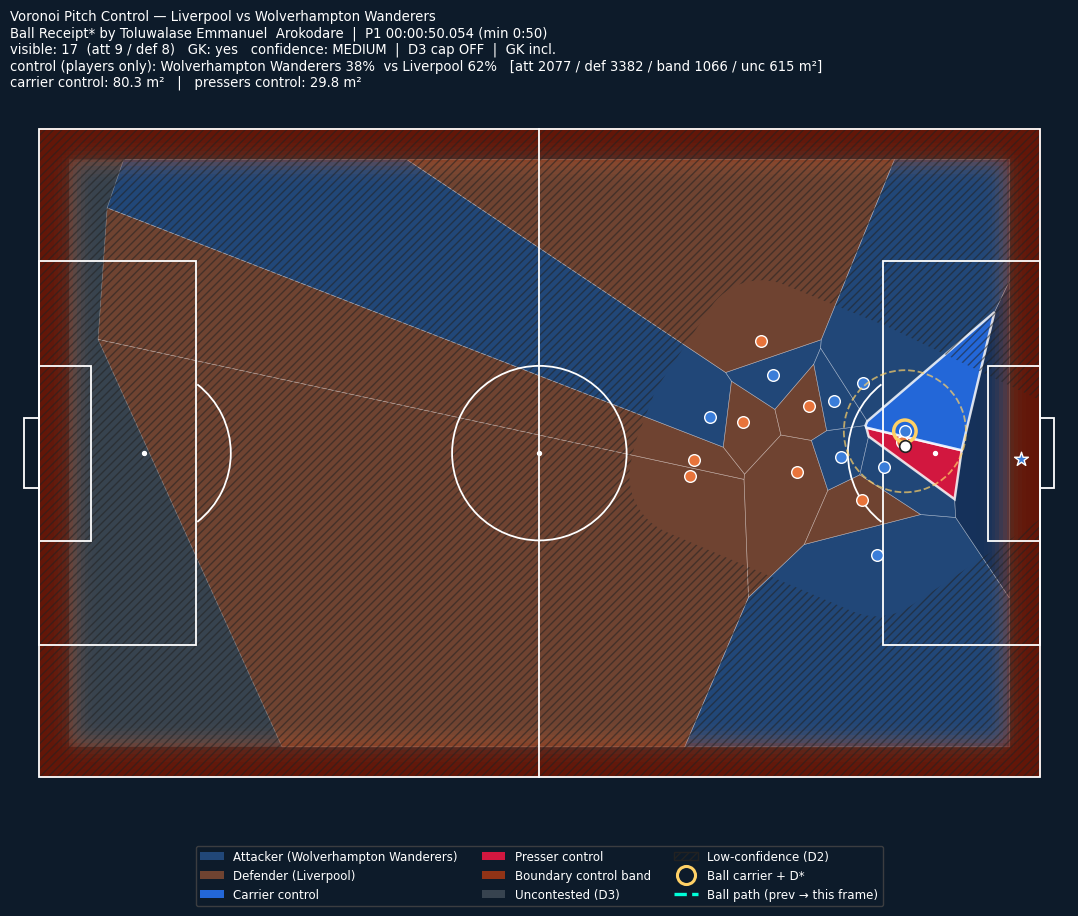

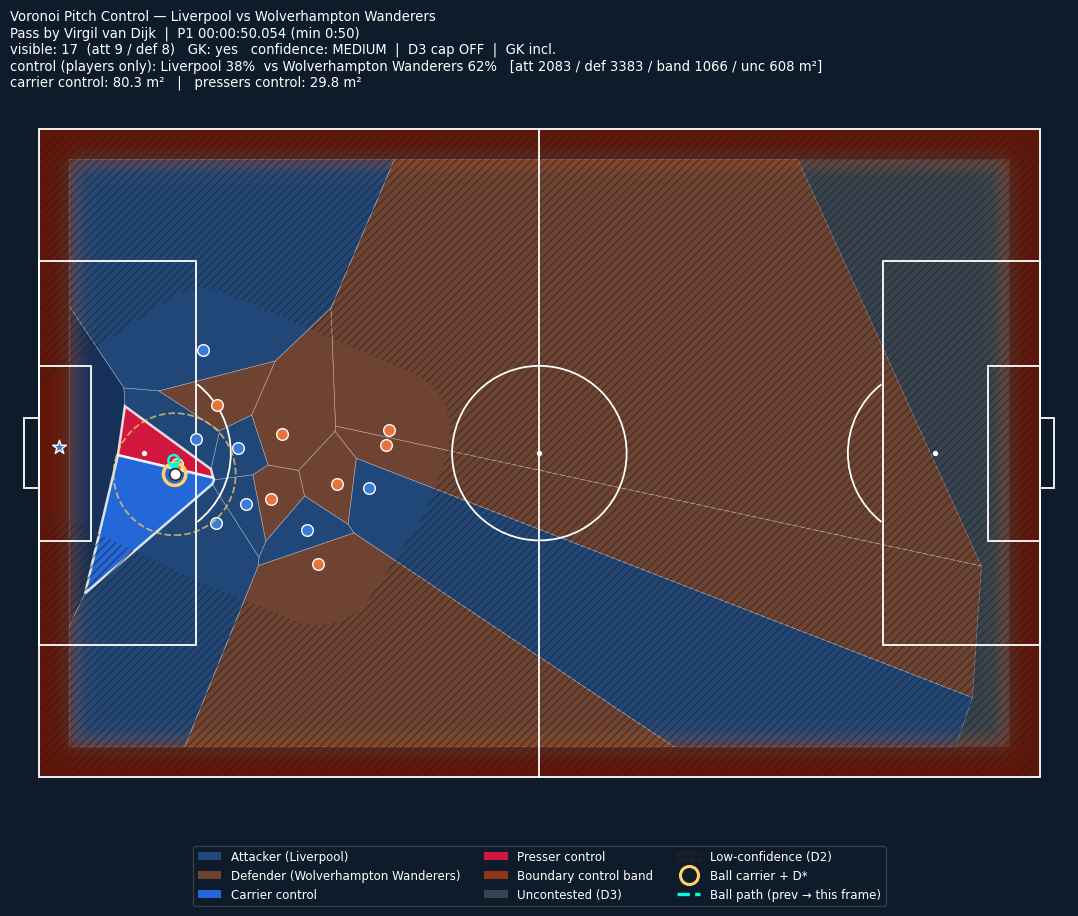

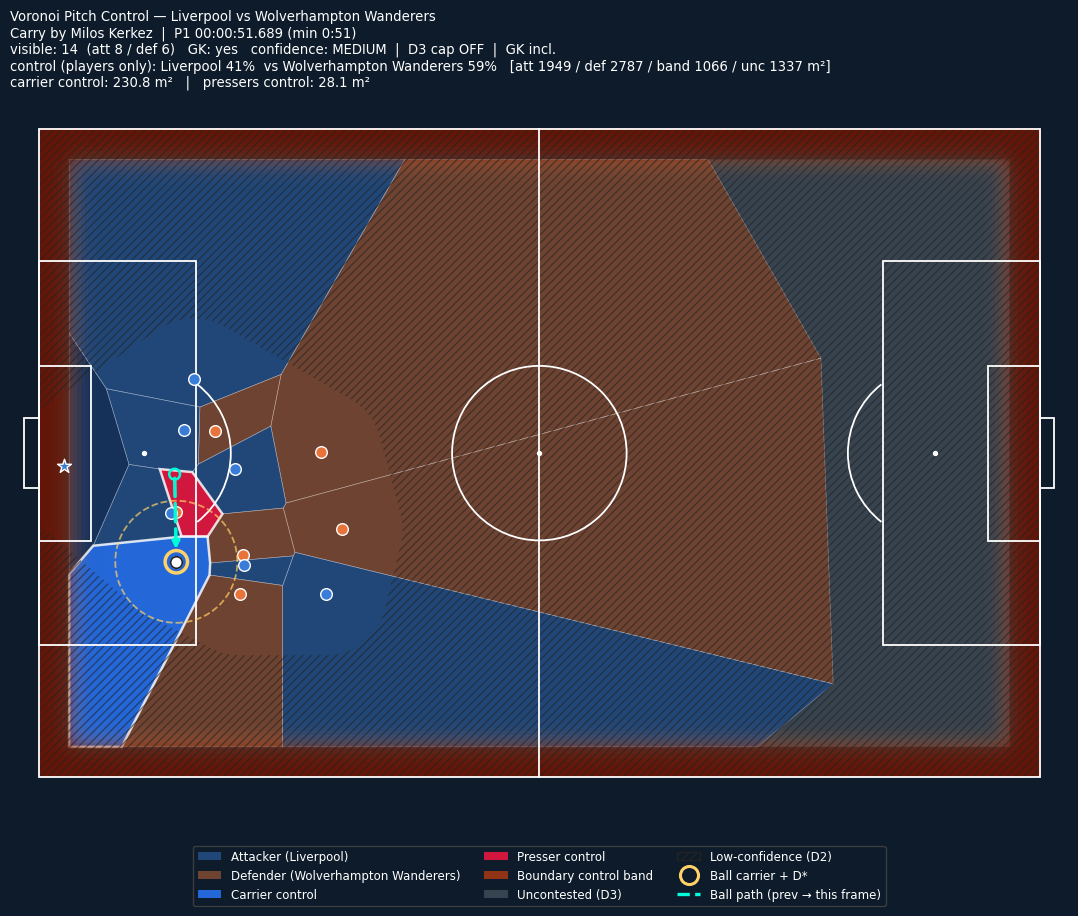

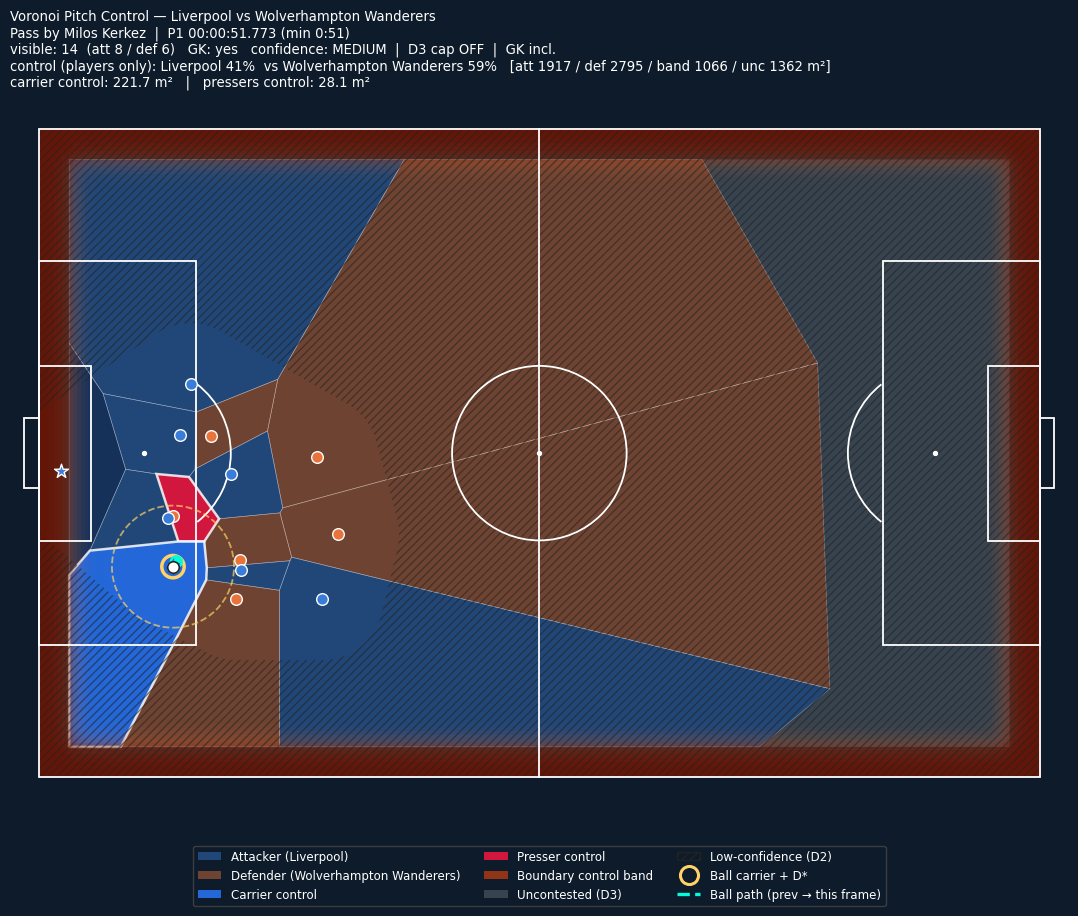

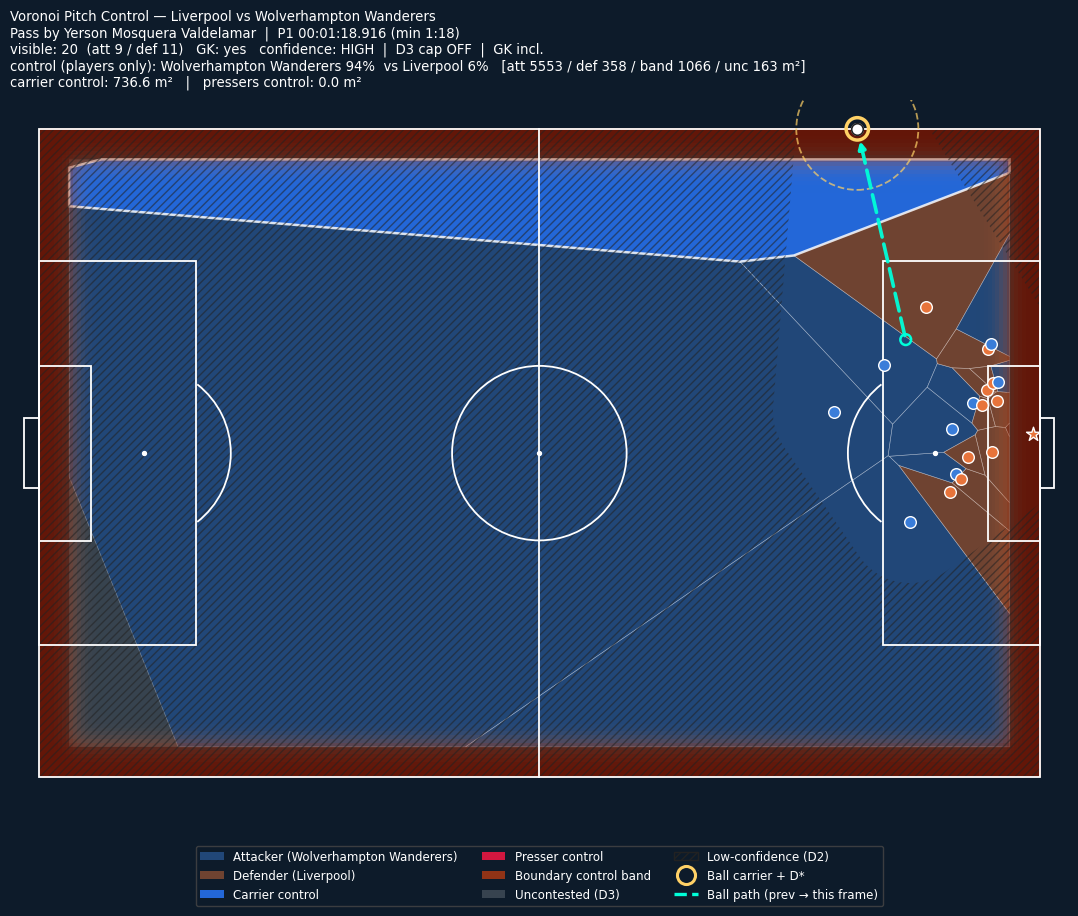

In [7]:
# Cell 6 — Single frame: full tessellation (D2) vs reachable-capped (D3)
# Pick any event from the lists in Cell 5a:
#   SEQ1/SEQ2/SEQ3 (all frames)  or  SEQ1_HP/SEQ2_HP/SEQ3_HP (high_press only)
EVENT_ID = SEQ1_HP[2]

for i in SEQ1:
    fig = plot_voronoi(i, cap_reachable=False)   # full tessellation
    plt.show()



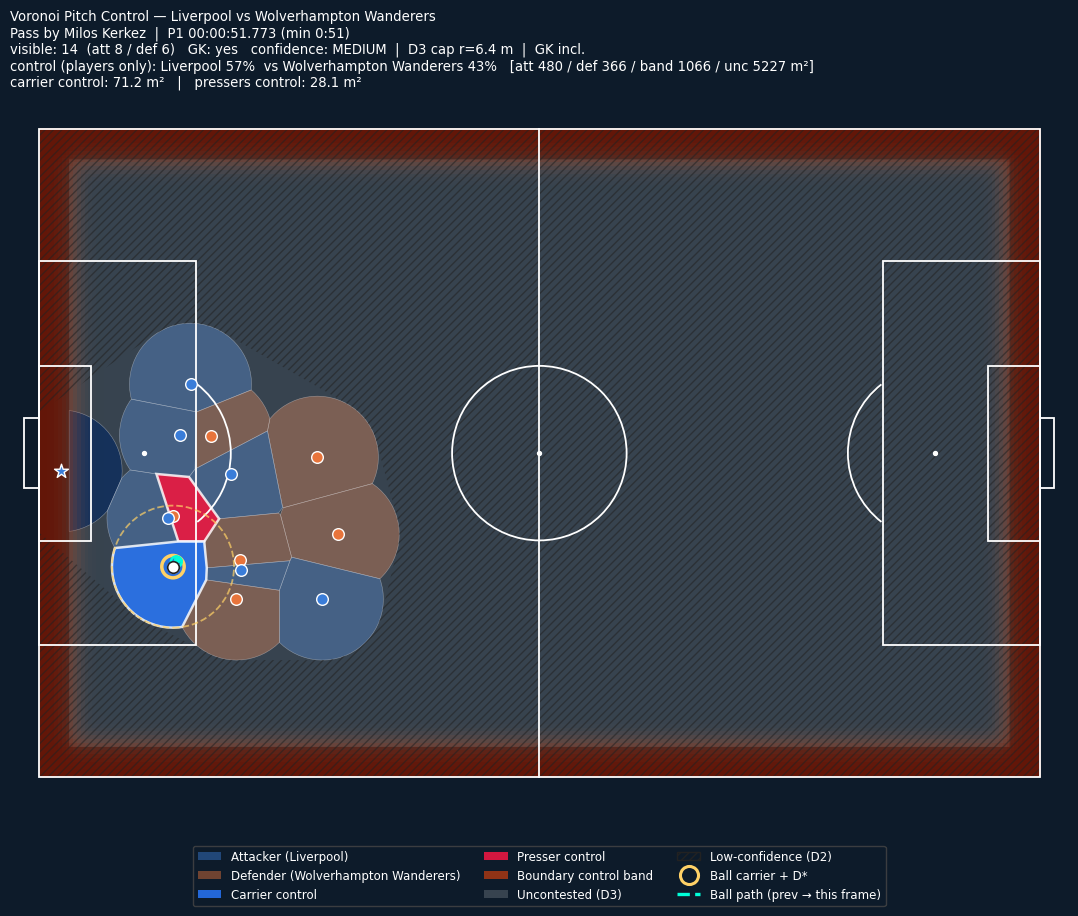

Per-cell features (D4):
    team  is_keeper  is_actor  area_m2  frac_in_band  inside_hull  capped    x    y
defender      False     False   102.42         0.064         True    True 29.2 33.6
attacker      False     False    92.49         0.174         True    True 29.8 18.7
attacker      False     False    89.77         0.206         True    True 15.9 41.2
defender      False     False    88.45         0.000         True    True 31.4 25.5
attacker      False      True    71.16         0.257         True    True 14.1 22.1
defender      False     False    67.03         0.211         True    True 20.7 18.7
attacker      False     False    56.92         0.000         True    True 20.2 31.8
attacker      False     False    54.84         0.000         True    True 14.9 35.9
attacker       True     False    52.87         0.520         True    True  2.4 32.1
attacker      False     False    44.04         0.000         True    True 13.6 27.2
defender      False     False    41.38         0.000

In [8]:
fig, cells = plot_voronoi(EVENT_ID, cap_reachable=True, radius=D_PLAYER,
                          return_table=True)         # honest capped control
plt.show()

# D4 cell table — filter to confident cells for downstream use
print("Per-cell features (D4):")
print(cells.sort_values("area_m2", ascending=False).to_string(index=False))

## Sequence — small-multiples + control-area trend

Plots every frame of one high-pressure sequence (attacking team always left → right), followed by a line chart of how much space the **carrier** vs the **pressers** control across the sequence.

Areas use the **reachable-capped** tessellation, so the trend reflects only space within `D* = 6.4 m` of a player (it ignores out-of-reach territory and stays honest). Set `SEQ_ID` and run.

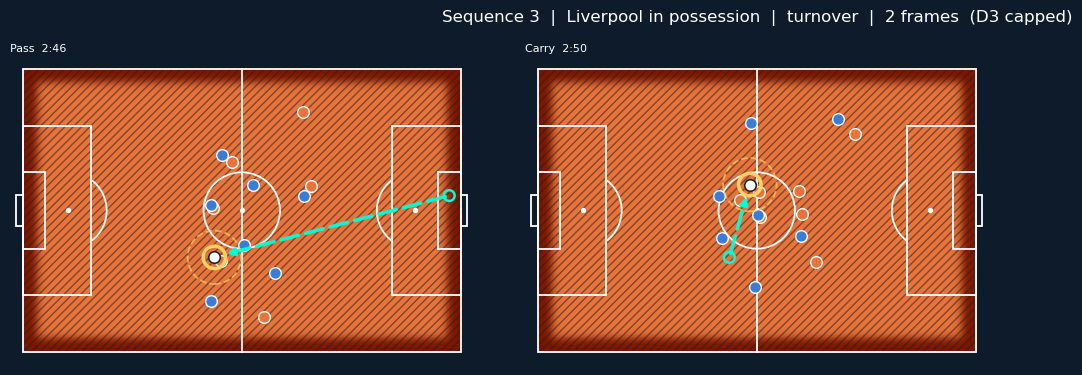

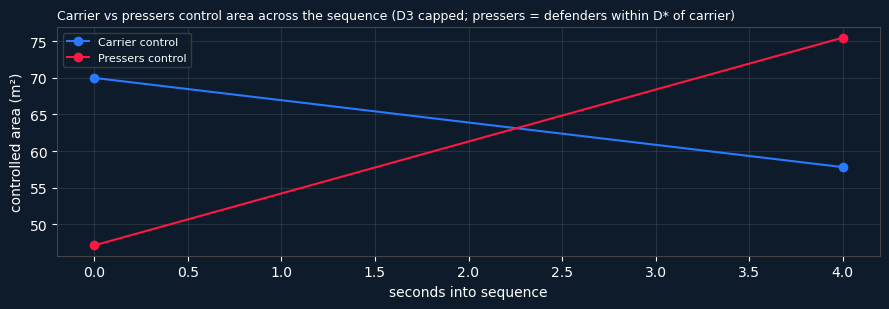

In [9]:
# Cell 7 — Sequence small-multiples + carrier/presser control-area trend

def plot_sequence_voronoi(seq_id, cap_reachable=True, include_keeper=True,
                          ncols=3, roles=("high_press",)):
    """Grid of Voronoi frames for one sequence + a carrier/presser area trend."""
    sub = seq_df[(seq_df.seq_id == seq_id) & (seq_df.frame_role.isin(roles))]
    sub = sub[sub["id"].isin(frames)].sort_values("ev_pos")
    ids = sub["id"].tolist()
    if not ids:
        print(f"seq {seq_id}: no plottable frames"); return

    n = len(ids)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 3.7 * nrows))
    fig.patch.set_facecolor(CLR_BG)
    axes = np.atleast_1d(axes).flatten()

    trend = []
    for k, eid in enumerate(ids):
        res, meta, _ = render_voronoi(axes[k], eid, cap_reachable=cap_reachable,
                                      include_keeper=include_keeper, boundary_grid=True)
        ca = res.get("carrier_area_m2")
        pa = res.get("presser_area_m2")
        trend.append((meta["minute"] * 60 + meta["second"],
                      ca if ca is not None else np.nan,
                      pa if pa is not None else np.nan))
        axes[k].set_title(f"{meta['type']}  {meta['minute']}:{meta['second']:02d}",
                          fontsize=8, color="white", loc="left", pad=3)
    for k in range(n, len(axes)):
        axes[k].set_visible(False)

    meta0 = seq_df[seq_df.seq_id == seq_id].iloc[0]
    fig.suptitle(f"Sequence {seq_id}  |  {meta0['possession_team']} in possession  "
                 f"|  {meta0['end_reason']}  |  {n} frames  (D3 capped)",
                 color="white", fontsize=12, y=1.0)
    plt.tight_layout()
    plt.show()

    # Carrier vs presser control-area trend
    t0 = trend[0][0]
    ts  = [t - t0 for t, _, _ in trend]
    car = [c for _, c, _ in trend]
    prs = [p for _, _, p in trend]
    fig2, ax2 = plt.subplots(figsize=(9, 3.2))
    fig2.patch.set_facecolor(CLR_BG); ax2.set_facecolor(CLR_BG)
    ax2.plot(ts, car, "-o", color=CLR_CARRIER, label="Carrier control")
    ax2.plot(ts, prs, "-o", color=CLR_PRESSER, label="Pressers control")
    ax2.set_xlabel("seconds into sequence", color="white")
    ax2.set_ylabel("controlled area (m²)", color="white")
    ax2.tick_params(colors="white")
    for s in ax2.spines.values(): s.set_color("#444")
    ax2.legend(fontsize=8, facecolor=CLR_BG, edgecolor="#444", labelcolor="white")
    ax2.set_title("Carrier vs pressers control area across the sequence "
                  "(D3 capped; pressers = defenders within D* of carrier)",
                  color="white", fontsize=9, loc="left")
    ax2.grid(alpha=0.15)
    plt.tight_layout()
    plt.show()


SEQ_ID = 3
plot_sequence_voronoi(SEQ_ID, cap_reachable=True)

# Heterogeneous Pressure-Network Graph (HPN v2)

A typed heterograph anchored to the metric pitch — the object fed to a HeteroGNN. Design principle: **role on the node type, strength on the edge weight**; sparse, directed, interpretable. Crucially: *don't hand-feed a quantity that message passing can already learn.* Same conventions as the Voronoi part (`sb_to_m` → 105×68 m, attack toward x=105, shared `D* / k` params).

> This notebook builds + **draws** the graph (schema §2–§5). The `HeteroData` conversion (`ToUndirected`, empty-tensor padding) and the read-out head live in the GNN skeleton notebook (design §6–§7).

## Nodes — 5 folded types

| type | meaning | folded from |
| --- | --- | --- |
| `ball_carrier` | the actor (even if a keeper) | carrier |
| `attacker` | possession-team outfield (non-actor) | — |
| `defender` | pressing-team outfield | presser + defender merged |
| `keeper` | either keeper (in-possession GK = back-pass outlet) | gk_att / gk_def |
| `boundary` | **virtual**: nearest-edge foot of the carrier | line |

`goal_*` and loose-`ball` nodes are dropped. **No separate `presser` type** — pressing strength rides the `press` edge.

## Node features — `NODE_FEAT_DIM = 10` (was 12; last channel = `visible_mask`)

`x, y, dist_ref, prev_x, prev_y, friendly_density, enemy_density, dist_boundary, under_pressure_sb, visible_mask`.

- **Dropped** `dist_near_enemy` / `dist_near_friend` (12→10): demoted to **edges** as the `near_enemy` / `near_friend` k=1 relations — directed, so strictly more informative than the old undirected scalar.
- **Kept** `dist_ref`, `dist_boundary` — intrinsic geometric anchors, robust to edge pruning; and `friendly_density` / `enemy_density` — neighbour **counts**, which GAT's softmax attention normalises away and cannot rebuild via message passing.
- `prev_x/prev_y` = previous-frame ball position (broadcast) — a motion cue (360 has no velocity); role/team are encoded by node type, not features.

## Edges — two feature classes, each a displacement vector + (optional) weight

`[dist_x, dist_y, angle]` always; a `weight` channel **only where it carries multi-body info a single src→dst geometry can't recover**.

| edge | dir | weight? | feature | build rule |
| --- | --- | --- | --- | --- |
| `pass` | carrier → attacker / keeper | **yes** | `[w, dx, dy, ang]` | `w = 0.5·lane openness + 0.5·receiver freedom`: lane = ∏(1−p) over defenders on the segment (`D_lane=1.2 m, k≈3.02`, soft `R_SOFT=2 m`); receiver freedom = ∏(1−p) of defenders around the target (`D*_player=6.4 m`) |
| `trap` 🔹opt | boundary → carrier | **yes** | `[w, dx, dy, ang]` | corner-aware `1 − ∏_b(1−p_line)` over 4 lines (`D*_line=3.2 m`) |
| `press` | defender → carrier / attacker | no | `[dx, dy, ang]` | nearest 2 attacking targets, kept if `sigmoid(k_player,6.4,d)>0.05` |
| `coop` | attacker ↔ attacker | no | `[dx, dy, ang]` | **Delaunay** triangulation over attacking outfield (minus carrier & keeper); edge dropped where lane block `1−∏(1−p) ≥ 0.5` (`COOP_BLOCK_TH`), **or** where it geometrically crosses a `pass` lane (pass priority) |
| `near_enemy` | player → nearest enemy | no | `[dx, dy, ang]` | k=1 directed |
| `near_friend` | player → nearest friend | no | `[dx, dy, ang]` | k=1 directed |

**Why split**: `press`/`coop`/`near_*` strengths are monotone functions of `‖dx,dy‖`, i.e. redundant with the displacement vector — so their `weight` channel is removed and the distance→pressure nonlinearity is left to GAT. `pass`/`trap` weights aggregate over *many* defenders / *four* lines, which a lone edge geometry cannot reconstruct — so they stay.

> For drawing only, every edge also carries `disp ∈ [0,1]` (geometric display intensity → line width/alpha); `disp` is **never** a GNN feature. Undirected `coop` is drawn once; `ToUndirected()` materialises reverse keys on the GNN side. Future ball direction never enters features (leakage) — labels/arrows only.


In [10]:
# Cell 8 — HPN v2 builder (5 node types, semantic edges) + heterograph drawing
import math
from collections import Counter
from matplotlib.patches import FancyArrowPatch, Arc
from pressure_distance_v2 import sigmoid_pressure, PressureParams
from pressure_graph import carrier_total_pressure

PARAMS = PressureParams()

# ── constants (single source: design §8 / high-press skill §1) ───────────────
K_PLAYER = PARAMS.k_player               # ≈0.821   press steepness
K_LINE   = PARAMS.k_line                 # ≈1.643   trap (boundary) steepness
P_EPS    = 0.05                          # press build threshold
R_SOFT   = 2.0                           # pass soft-boundary (to receiver)
SIGMA_COOP = 8.0     # coop display-intensity gaussian width (topology: Delaunay + pruning, below)
PRESS_K_TARGETS              = 2                # press: nearest-k attacking targets
# `pass` lane corridor is narrow → keep dedicated lane params (extends §8, from pressure_graph)
D_LANE = 1.2
K_LANE = math.pi / (math.sqrt(3) * 0.6)  # ≈3.02

NODE_TYPES_V2 = ["ball_carrier", "attacker", "defender", "keeper", "boundary"]

# Edge-feature contract (assembled in the GNN skeleton):
#   pass / trap            → [weight, dist_x, dist_y, angle]   (weight = multi-body aggregate, NOT recoverable)
#   press / coop /          → [dist_x, dist_y, angle]           (strength is a monotone fn of distance →
#   near_enemy/near_friend                                       redundant with dist_x/dist_y; left to GAT)
WEIGHTED_RELATIONS = {"pass", "trap"}
from scipy.spatial import Delaunay
def _seg_cross(p1, p2, p3, p4):
    """True iff segments p1p2 and p3p4 cross in their interiors (shared endpoints excluded)."""
    p1, p2, p3, p4 = (tuple(map(float, q)) for q in (p1, p2, p3, p4))
    if p3 in (p1, p2) or p4 in (p1, p2):         # share an endpoint -> not a crossing
        return False
    def orient(a, b, c):
        return (b[0]-a[0])*(c[1]-a[1]) - (b[1]-a[1])*(c[0]-a[0])
    d1, d2 = orient(p3, p4, p1), orient(p3, p4, p2)
    d3, d4 = orient(p1, p2, p3), orient(p1, p2, p4)
    return ((d1 > 0) != (d2 > 0)) and ((d3 > 0) != (d4 > 0))
COOP_BLOCK_TH = 0.5     # coop: defensive influence (1 - lane openness) >= this -> sever the link
def _lane_block(a_xy, b_xy, def_of, pos, soft_both=False):
    """Segment a->b openness = prod(1-p) over defenders inside the corridor (same as `pass`).
    soft_both=True also checks an R_SOFT soft-region around BOTH endpoints (coop is undirected)."""
    block = 1.0
    for j in def_of:
        e_d, t = _perp(pos[j], a_xy, b_xy)
        if 0.0 <= t <= 1.0:
            block *= (1.0 - sigmoid_pressure(K_LANE, D_LANE, e_d))
        else:
            ends = (a_xy, b_xy) if soft_both else (b_xy,)
            for xy in ends:
                dd = float(np.linalg.norm(pos[j] - xy))
                if dd <= R_SOFT:
                    block *= (1.0 - sigmoid_pressure(K_LANE, D_LANE, dd))
    return block

# ── HPN v2 drawing style ─────────────────────────────────────────────────────
# Restrained two-family palette: ATTACK = cool, DEFEND = warm, boundary = neutral grey.
CLR_PITCH   = "#cfe3c0"   # light turf green (figure + axes background)
CLR_PITCHLN = "#ffffff"   # pitch lines, drawn thin + faint
CLR_ATTACK  = "#2F6FD0"   # cool — attacker fill
CLR_ATT_GK  = "#1B3F86"   # cool deep — attacking keeper
CLR_DEFEND  = "#E8743B"   # warm — defender fill
CLR_DEF_GK2 = "#A6320F"   # warm deep — defending keeper
CLR_STAR    = "#FF2A2A"   # ball carrier — red star (focus)
CLR_FOCUS   = "#0E2A52"   # attack-direction arrow / accents
CLR_BND     = "#7A7F87"   # boundary foot (neutral grey)
CLR_E_PASS  = "#2F6FD0"   # cool solid — pass
CLR_E_COOP  = "#86B5EC"   # cool light — coop
CLR_E_PRESS = "#D9480F"   # warm solid — press
CLR_E_TRAP  = "#7A7F87"   # neutral grey dashed — trap

NODE_SIZE = 80            # shrunk so the network edges stay visible

# Drawn relations (near_enemy/near_friend stay in the graph data but are hidden).
DRAW_RELATIONS = {"pass", "coop", "press", "trap"}
# per relation: (color, lw-scale, linestyle, arrow, zorder, alpha)
EDGE_STYLE = {
    "coop":  (CLR_E_COOP,  2.2, "-",  False, 0.8, 0.70),
    "trap":  (CLR_E_TRAP,  4.0, "--", True,  1.0, 0.75),
    "pass":  (CLR_E_PASS,  5.0, "-",  False, 1.4, 0.90),
    "press": (CLR_E_PRESS, 5.5, "-",  True,  2.0, 0.90),
}


def _perp(p, a, b):
    """Perpendicular distance of p to segment a→b and projection param t."""
    a, b, p = np.asarray(a), np.asarray(b), np.asarray(p)
    ab = b - a; L2 = float(ab @ ab)
    if L2 == 0:
        return float(np.linalg.norm(p - a)), 0.0
    t = float((p - a) @ ab) / L2
    return float(np.linalg.norm(p - (a + t * ab))), t


def _nearest_boundary(ref):
    """Nearest-edge foot, its distance, side name, and corner-aware boundary pressure."""
    cx, cy = float(ref[0]), float(ref[1])
    cands = {"left": ((0.0, cy), cx), "right": ((PITCH_L, cy), PITCH_L - cx),
             "bottom": ((cx, 0.0), cy), "top": ((cx, PITCH_W), PITCH_W - cy)}
    side = min(cands, key=lambda k: cands[k][1])
    prod = 1.0
    for _, d in cands.values():
        prod *= (1.0 - sigmoid_pressure(K_LINE, PARAMS.D_star_line, d))
    return np.array(cands[side][0]), cands[side][1], side, 1.0 - prod


def build_hpn_v2(players, ball_xy=None, prev_ball_xy=None, under_pressure=False,
                 with_trap=True):
    """metric players → (nodes, edges, global_ctx) under the v2 schema.
    Nodes carry 10 features (NN distances dropped → near_enemy/near_friend edges)."""
    pos = np.array([[p["x"], p["y"]] for p in players], float)
    n = len(players)
    carrier_i = next((i for i, p in enumerate(players) if p["actor"]), None)
    has_carrier = carrier_i is not None
    ref = (pos[carrier_i] if has_carrier else
           (np.array(ball_xy, float) if ball_xy is not None else pos.mean(0)))
    d_ref = np.linalg.norm(pos - ref, axis=1)

    # ── node folding (5 types; no presser) ──
    types = []
    for p in players:
        if p["actor"]:           types.append("ball_carrier")
        elif p["keeper"]:        types.append("keeper")
        elif p["team"] == "attacker": types.append("attacker")
        else:                    types.append("defender")

    atk_idx = [i for i in range(n) if players[i]["team"] == "attacker"]
    def_idx = [i for i in range(n) if players[i]["team"] == "defender"]
    def_of  = [i for i in def_idx if not players[i]["keeper"]]
    atk_of  = [i for i in atk_idx if not players[i]["keeper"] and not players[i]["actor"]]
    atk_recv = [i for i in atk_idx if not players[i]["actor"]]      # pass targets (incl. GK outlet)
    press_targets = ([carrier_i] if has_carrier else []) + atk_of

    def density(idx_set, i, R=10.0):
        return int(sum(1 for j in idx_set if j != i and np.linalg.norm(pos[i] - pos[j]) <= R))

    pbx, pby = (prev_ball_xy if prev_ball_xy is not None else (None, None))

    # ── real nodes (10 features; NN distances now live on near_* edges) ──
    nodes = []
    for i in range(n):
        friend = atk_idx if players[i]["team"] == "attacker" else def_idx
        enemy  = def_idx if players[i]["team"] == "attacker" else atk_idx
        _, dbnd, _, _ = _nearest_boundary(pos[i])
        nodes.append({
            "id": i, "type": types[i], "team": players[i]["team"],
            "is_keeper": bool(players[i]["keeper"]),
            "x": round(float(pos[i, 0]), 2), "y": round(float(pos[i, 1]), 2),
            "dist_ref": round(float(d_ref[i]), 2),
            "prev_x": round(float(pbx), 2) if pbx is not None else 0.0,
            "prev_y": round(float(pby), 2) if pby is not None else 0.0,
            "friendly_density": density(friend, i),
            "enemy_density":    density(enemy, i),
            "dist_boundary":    round(float(dbnd), 2),
            "under_pressure_sb": int(1 if (types[i] == "ball_carrier" and under_pressure) else 0),
            "visible_mask": 1,
        })

    # ── virtual boundary node (geometric anchor; weight on the trap edge) ──
    bfoot, _, bside, bpij = _nearest_boundary(ref)
    nodes.append({
        "id": "boundary", "type": "boundary", "team": "neutral", "is_keeper": False,
        "x": round(float(bfoot[0]), 2), "y": round(float(bfoot[1]), 2),
        "dist_ref": round(float(np.linalg.norm(bfoot - ref)), 2),
        "prev_x": 0.0, "prev_y": 0.0, "friendly_density": 0, "enemy_density": 0,
        "dist_boundary": 0.0, "under_pressure_sb": 0, "visible_mask": 1, "side": bside,
    })

    posmap = {nd["id"]: (nd["x"], nd["y"]) for nd in nodes}

    def E(s, d, rel, disp, directed, feat_w=None):
        """disp = display intensity (always); feat_w = GNN feature weight (pass/trap only)."""
        sx, sy = posmap[s]; dx_, dy_ = posmap[d]
        ddx, ddy = dx_ - sx, dy_ - sy
        return {"src": s, "dst": d, "etype": rel,
                "weight": (round(float(feat_w), 4) if feat_w is not None else None),
                "disp": round(float(disp), 4),
                "dist_x": round(ddx, 2), "dist_y": round(ddy, 2),
                "angle_relative": round(float(np.arctan2(ddy, ddx)), 4), "directed": directed}

    edges = []

    # 1) pass — carrier → every receiver. weight = 0.5*lane openness + 0.5*receiver freedom (KEPT).
    if has_carrier:
        for r in atk_recv:
            block = 1.0
            for j in def_of:
                e_d, t = _perp(pos[j], ref, pos[r])
                if 0.0 <= t <= 1.0:
                    block *= (1.0 - sigmoid_pressure(K_LANE, D_LANE, e_d))
                else:
                    d_recv = float(np.linalg.norm(pos[j] - pos[r]))
                    if d_recv <= R_SOFT:
                        block *= (1.0 - sigmoid_pressure(K_LANE, D_LANE, d_recv))
            # NEW: receiver freedom under surrounding defensive pressure (player params, 6.4 m)
            recv_free = 1.0
            for j in def_of:
                d_jr = float(np.linalg.norm(pos[j] - pos[r]))
                recv_free *= (1.0 - sigmoid_pressure(K_PLAYER, PARAMS.D_star_player, d_jr))
            w = 0.5 * block + 0.5 * recv_free          # 50% lane openness + 50% receiver freedom
            edges.append(E(carrier_i, r, "pass", disp=w, directed=True, feat_w=w))

    # 2) coop — Delaunay among attacking outfield (minus carrier); drop if lane block >= 0.5
    #          OR if the link crosses a pass lane (pass priority). weight DROPPED.
    coop_nodes = atk_of                          # attacking outfield, minus carrier & keeper
    cand = set()
    if len(coop_nodes) >= 3:
        try:
            tri = Delaunay(pos[coop_nodes])
            for smp in tri.simplices:
                for u in range(3):
                    for v in range(u + 1, 3):
                        cand.add(frozenset((coop_nodes[smp[u]], coop_nodes[smp[v]])))
        except Exception:                        # collinear / degenerate -> complete graph fallback
            cand = {frozenset((a, b)) for a in coop_nodes for b in coop_nodes if a < b}
    elif len(coop_nodes) == 2:
        cand = {frozenset(coop_nodes)}
    pass_segs = [(pos[e["src"]], pos[e["dst"]]) for e in edges if e["etype"] == "pass"]
    for pair in cand:
        a, b = tuple(pair)
        block = _lane_block(pos[a], pos[b], def_of, pos, soft_both=True)
        if (1.0 - block) >= COOP_BLOCK_TH:       # defenders sever this support link
            continue
        if any(_seg_cross(pos[a], pos[b], ps, pe) for ps, pe in pass_segs):
            continue                             # coop crosses a passing lane -> drop (pass priority)
        d = float(np.linalg.norm(pos[a] - pos[b]))
        disp = math.exp(-d * d / (2 * SIGMA_COOP * SIGMA_COOP))   # display intensity only (not a GNN feature)
        edges.append(E(a, b, "coop", disp=disp, directed=False))
        edges.append(E(b, a, "coop", disp=disp, directed=False))

    # 3) press — defender → nearest PRESS_K_TARGETS attacking targets (p>EPS). weight DROPPED.
    for j in def_of:
        tgts = sorted(press_targets, key=lambda k: np.linalg.norm(pos[j] - pos[k]))[:PRESS_K_TARGETS]
        for k in tgts:
            d = float(np.linalg.norm(pos[j] - pos[k]))
            p = sigmoid_pressure(K_PLAYER, PARAMS.D_star_player, d)
            if p > P_EPS:
                edges.append(E(j, k, "press", disp=p, directed=True))

    # 4) near_enemy / near_friend — k=1 directed NN edges (carry the distance dropped from nodes).
    for i in range(n):
        enemy  = def_idx if players[i]["team"] == "attacker" else atk_idx
        friend = atk_idx if players[i]["team"] == "attacker" else def_idx
        for grp, rel in ((enemy, "near_enemy"), (friend, "near_friend")):
            cand = [j for j in grp if j != i]
            if not cand:
                continue
            j = min(cand, key=lambda k: np.linalg.norm(pos[i] - pos[k]))
            disp = sigmoid_pressure(K_PLAYER, PARAMS.D_star_player,
                                    float(np.linalg.norm(pos[i] - pos[j])))
            edges.append(E(i, j, rel, disp=disp, directed=True))

    # 5) trap (optional) — boundary → carrier, corner-aware. weight KEPT (4-line aggregate).
    if with_trap and has_carrier:
        edges.append(E("boundary", carrier_i, "trap", disp=bpij, directed=True, feat_w=bpij))

    # ── global context (ball; PAST info only, leak-free) ──
    ball_pos = ball_xy if ball_xy is not None else (ref.tolist() if has_carrier else None)
    if prev_ball_xy is not None and ball_pos is not None:
        ddx, ddy = ball_pos[0] - prev_ball_xy[0], ball_pos[1] - prev_ball_xy[1]
        gctx = {"ball_xy": [round(float(ball_pos[0]), 2), round(float(ball_pos[1]), 2)],
                "ball_state": "carried" if has_carrier else "loose",
                "ball_in_dist": round(float(math.hypot(ddx, ddy)), 2),
                "ball_in_angle": round(float(math.atan2(ddy, ddx)), 4), "ball_in_mask": 1}
    else:
        gctx = {"ball_xy": ([round(float(ball_pos[0]), 2), round(float(ball_pos[1]), 2)]
                            if ball_pos is not None else None),
                "ball_state": "carried" if has_carrier else "loose",
                "ball_in_dist": None, "ball_in_angle": None, "ball_in_mask": 0}

    return nodes, edges, gctx


def event_graph(event_id, with_trap=True):
    """Build the v2 heterograph for one event_id. Returns (nodes, edges, meta)."""
    players, meta = extract_players(event_id)
    nodes, edges, gctx = build_hpn_v2(players, ball_xy=meta["ball_xy"],
                                      prev_ball_xy=meta["prev_ball_xy"],
                                      under_pressure=meta["under_pressure"],
                                      with_trap=with_trap)
    meta["P_total"]    = carrier_total_pressure(players)
    meta["global_ctx"] = gctx
    return nodes, edges, meta


def _pitch_faint(ax):
    """Light-green pitch as a faint spatial reference (thin, pale lines)."""
    ax.set_facecolor(CLR_PITCH)
    ax.set_aspect("equal"); ax.axis("off")
    lc, lw, la, z = CLR_PITCHLN, 1.4, 1.0, 0.5   # near-solid white lines
    def rect(x, y, w, h):
        ax.add_patch(mpatches.Rectangle((x, y), w, h, fill=False, edgecolor=lc,
                                        lw=lw, alpha=la, zorder=z))
    rect(0, 0, 105, 68)
    ax.plot([52.5, 52.5], [0, 68], color=lc, lw=lw, alpha=la, zorder=z)
    ax.add_patch(Circle((52.5, 34), 9.15, fill=False, edgecolor=lc, lw=lw, alpha=la, zorder=z))
    rect(0, 13.84, 16.5, 40.32); rect(88.5, 13.84, 16.5, 40.32)   # penalty areas
    rect(0, 24.84, 5.5, 18.32);  rect(99.5, 24.84, 5.5, 18.32)    # six-yard boxes
    ax.scatter([11, 94], [34, 34], s=5, color=lc, alpha=la, zorder=z)


def _attack_arrow(ax):
    """Attacking direction marker (possession attacks toward x=105 → rightwards)."""
    ax.annotate("", xy=(0.20, 0.97), xytext=(0.03, 0.97), xycoords="axes fraction",
                arrowprops=dict(arrowstyle="-|>", color=CLR_FOCUS, lw=2.0))
    ax.text(0.215, 0.97, "attack", transform=ax.transAxes, fontsize=9,
            color=CLR_FOCUS, va="center", ha="left", fontweight="bold")


def draw_graph(ax, nodes, edges, meta, margin=9.0):
    """Schematic: faint pitch cropped to the local pressing region; pass/coop/press/trap."""
    bnd = next((n for n in nodes if n["type"] == "boundary"), None)
    real = [n for n in nodes if n["type"] != "boundary"]
    crop_pts = real + ([bnd] if (bnd is not None and "trap" in DRAW_RELATIONS) else [])
    xs = [n["x"] for n in crop_pts]; ys = [n["y"] for n in crop_pts]
    _pitch_faint(ax)
    ax.set_xlim(max(-5, min(xs) - margin), min(110, max(xs) + margin))   # allow space past the line
    ax.set_ylim(max(-5, min(ys) - margin), min(73, max(ys) + margin))

    posmap = {n["id"]: (n["x"], n["y"]) for n in nodes}

    # edges (drawn relations only; z-ordered; undirected coop drawn once)
    seen = set()
    drawable = [e for e in edges if e["etype"] in DRAW_RELATIONS]
    for e in sorted(drawable, key=lambda x: EDGE_STYLE[x["etype"]][4]):
        if not e["directed"]:
            key = (e["etype"], frozenset((e["src"], e["dst"])))
            if key in seen:
                continue
            seen.add(key)
        col, base, ls, arrow, z, a = EDGE_STYLE[e["etype"]]
        s, t = posmap[e["src"]], posmap[e["dst"]]
        lw = 0.5 + base * e["disp"]                       # weight → linewidth (single channel)
        if arrow:                                          # press / trap: directed → arrowhead
            ax.add_patch(FancyArrowPatch(s, t, arrowstyle="-|>", mutation_scale=10,
                         shrinkA=2, shrinkB=6, lw=lw, color=col, alpha=a, zorder=z, linestyle=ls))
        else:                                              # pass (radiating) / coop: plain line
            ax.plot([s[0], t[0]], [s[1], t[1]], color=col, lw=lw, alpha=a, linestyle=ls,
                    solid_capstyle="round", zorder=z)

    # nodes — circle = attacking side, square = defending side, triangle = boundary foot.
    # Sizes shrunk so edges stay visible; ball carrier = red star (focus).
    carrier = next((n for n in nodes if n["type"] == "ball_carrier"), None)
    if bnd is not None and "trap" in DRAW_RELATIONS:
        ax.scatter(bnd["x"], bnd["y"], marker="^", s=120, c=CLR_BND,
                   edgecolors=CLR_PITCH, linewidths=1.0, zorder=6)
    for n in real:
        if n["type"] == "ball_carrier":
            continue
        mk = "o" if n["team"] == "attacker" else "s"
        fc = (CLR_ATT_GK if (n["is_keeper"] and n["team"] == "attacker") else
              CLR_DEF_GK2 if n["is_keeper"] else
              CLR_ATTACK if n["team"] == "attacker" else CLR_DEFEND)
        ax.scatter(n["x"], n["y"], marker=mk, s=NODE_SIZE, c=fc,
                   edgecolors=CLR_PITCH, linewidths=1.0, zorder=6)
    if carrier:
        ax.scatter(carrier["x"], carrier["y"], marker="*", s=360, c=CLR_STAR,
                   edgecolors=CLR_PITCH, linewidths=1.2, zorder=7)

    _attack_arrow(ax)

print("HPN v2 builder + draw_graph ready  (style v2: + trap edge & boundary node).")


HPN v2 builder + draw_graph ready  (style v2: + trap edge & boundary node).


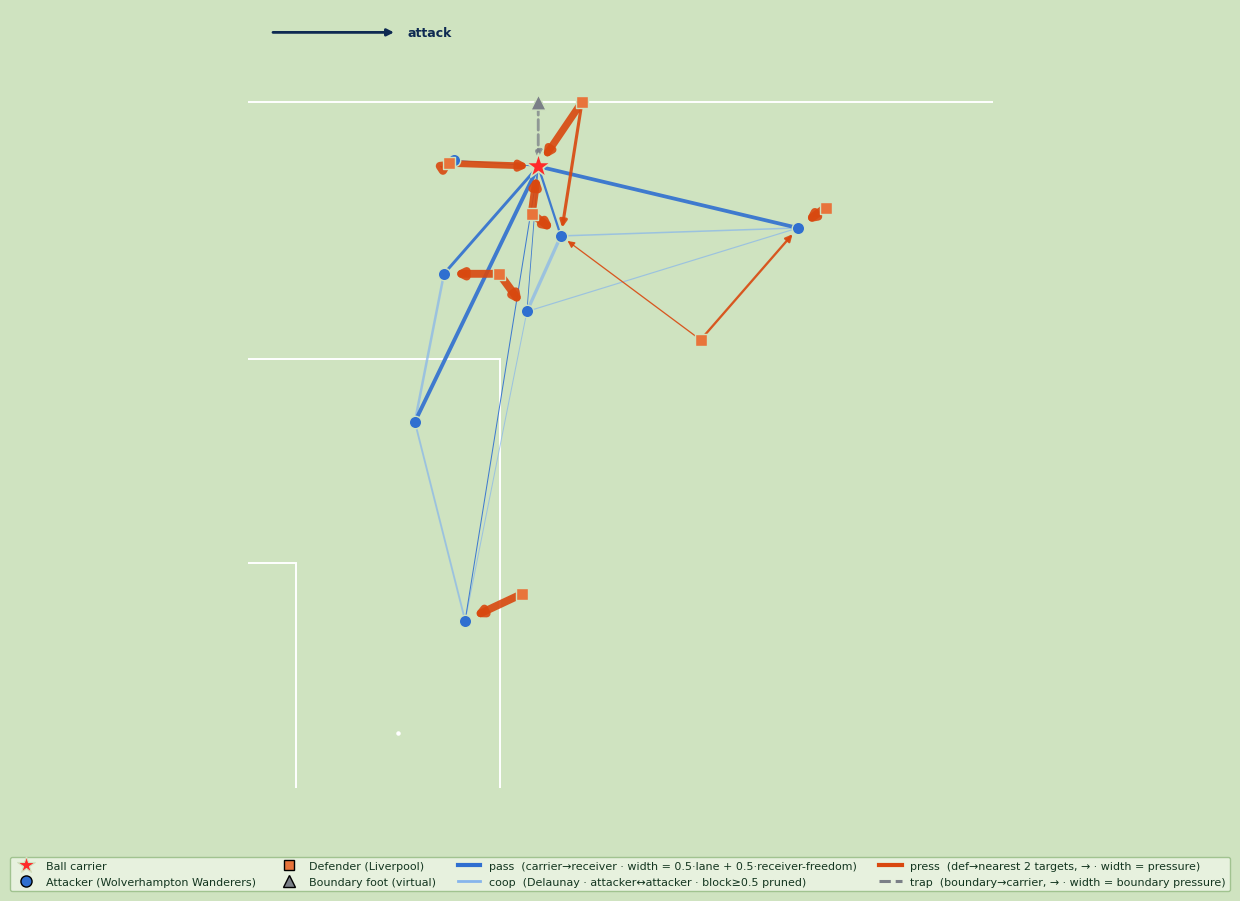

NODE TABLE (10 features — for GNN):
      id         type     team  is_keeper     x     y  dist_ref  prev_x  prev_y  friendly_density  enemy_density  dist_boundary  under_pressure_sb  visible_mask
       0     defender defender      False 34.04 62.30     15.64   18.73   63.92                 1              1           5.70                  0             1
       1     attacker attacker      False 32.55 61.20     14.39   18.73   63.92                 0              2           6.80                  0             1
       2     defender defender      False 27.30 55.17     12.81   18.73   63.92                 1              3          12.83                  0             1
       3     defender defender      False 20.91 68.00      4.21   18.73   63.92                 2              3           0.00                  0             1
       4 ball_carrier attacker      False 18.55 64.52      0.00   18.73   63.92                 4              4           3.48                  0             

In [11]:
# Cell 9 — plot_graph: schematic figure (light pitch, no title) + legend, and table export

CLR_TXT = "#13351f"   # dark green text on the light pitch background

def _graph_legend(meta):
    node_items = [
        Line2D([0],[0], marker="*", color="none", markerfacecolor=CLR_STAR, markersize=13,
               markeredgecolor=CLR_PITCH, markeredgewidth=0.8, label="Ball carrier"),
        Line2D([0],[0], marker="o", color="none", markerfacecolor=CLR_ATTACK, markersize=8,
               label=f"Attacker ({meta['atk_team']})"),
        Line2D([0],[0], marker="s", color="none", markerfacecolor=CLR_DEFEND, markersize=7,
               label=f"Defender ({meta['def_team']})"),
        Line2D([0],[0], marker="^", color="none", markerfacecolor=CLR_BND, markersize=8,
               label="Boundary foot (virtual)"),
    ]
    edge_items = [
        Line2D([0],[0], color=CLR_E_PASS,  lw=3, label="pass  (carrier→receiver · width = 0.5·lane + 0.5·receiver-freedom)"),
        Line2D([0],[0], color=CLR_E_COOP,  lw=2, label="coop  (Delaunay · attacker↔attacker · block≥0.5 pruned)"),
        Line2D([0],[0], color=CLR_E_PRESS, lw=3, label="press  (def→nearest 2 targets, → · width = pressure)"),
        Line2D([0],[0], color=CLR_E_TRAP,  lw=2.2, ls="--", label="trap  (boundary→carrier, → · width = boundary pressure)"),
    ]
    return node_items + edge_items


def plot_graph(event_id, with_trap=True, return_tables=False):
    nodes, edges, meta = event_graph(event_id, with_trap=with_trap)
    fig, ax = plt.subplots(figsize=(12, 9))
    fig.patch.set_facecolor(CLR_PITCH)
    draw_graph(ax, nodes, edges, meta)        # no title — clean schematic

    ax.legend(handles=_graph_legend(meta), loc="lower center",
              bbox_to_anchor=(0.5, -0.14), ncol=4, fontsize=8,
              framealpha=0.9, facecolor="#eaf3e2", edgecolor="#9bbf8a", labelcolor=CLR_TXT)
    plt.tight_layout()

    if return_tables:
        return fig, pd.DataFrame(nodes), pd.DataFrame(edges)
    return fig


# ── Single-frame example: a rich high-press frame (min 1:59, carrier under_pressure) ──
EXAMPLE_ID = "d5a8e3c8-f623-5698-9f21-d806594ef8d3"  # carrier ~3.5 m off the line → medium, visible trap
GRAPH_EVENT_ID = EXAMPLE_ID if (seq_df["id"] == EXAMPLE_ID).any() else \
    seq_df[(seq_df.frame_role == "high_press") & seq_df["id"].isin(frames)].iloc[0]["id"]

fig, node_df, edge_df = plot_graph(GRAPH_EVENT_ID, return_tables=True)
plt.show()

print("NODE TABLE (10 features — for GNN):")
print(node_df[["id","type","team","is_keeper","x","y","dist_ref","prev_x","prev_y",
               "friendly_density","enemy_density","dist_boundary",
               "under_pressure_sb","visible_mask"]].to_string(index=False))
print("\nEDGE TABLE (weight = GNN feature channel; None ⇒ distance-only relation):")
print(edge_df[["src","dst","etype","weight","disp","dist_x","dist_y","angle_relative","directed"]]
      .to_string(index=False))


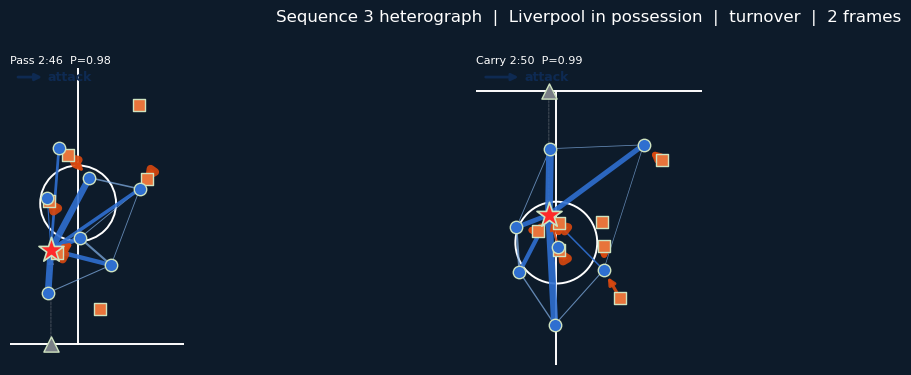

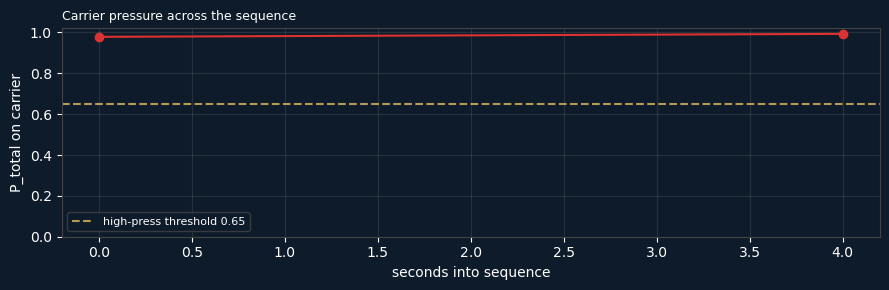

In [12]:
# Cell 10 — Sequence small-multiples of the heterograph + P_total trend

def plot_sequence_graph(seq_id, ncols=3):
    sub = seq_df[(seq_df.seq_id == seq_id) & (seq_df.frame_role == "high_press")]
    sub = sub[sub["id"].isin(frames)].sort_values("ev_pos")
    ids = sub["id"].tolist()
    if not ids:
        print(f"seq {seq_id}: no plottable frames"); return

    n = len(ids)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.2*ncols, 3.7*nrows))
    fig.patch.set_facecolor(CLR_BG)
    axes = np.atleast_1d(axes).flatten()

    trend = []
    for k, eid in enumerate(ids):
        nodes, edges, meta = event_graph(eid)
        draw_graph(axes[k], nodes, edges, meta)
        trend.append((meta["minute"]*60 + meta["second"], meta["P_total"]))
        axes[k].set_title(f"{meta['type']} {meta['minute']}:{meta['second']:02d}  "
                          f"P={meta['P_total']:.2f}",
                          fontsize=8, color="white", loc="left", pad=3)
    for k in range(n, len(axes)):
        axes[k].set_visible(False)

    meta0 = seq_df[seq_df.seq_id == seq_id].iloc[0]
    fig.suptitle(f"Sequence {seq_id} heterograph  |  {meta0['possession_team']} in possession  "
                 f"|  {meta0['end_reason']}  |  {n} frames",
                 color="white", fontsize=12, y=1.0)
    plt.tight_layout(); plt.show()

    # P_total trend
    t0 = trend[0][0]
    ts = [t - t0 for t, _ in trend]
    ps = [p for _, p in trend]
    fig2, ax2 = plt.subplots(figsize=(9, 3))
    fig2.patch.set_facecolor(CLR_BG); ax2.set_facecolor(CLR_BG)
    ax2.plot(ts, ps, "-o", color="#E03131")
    ax2.axhline(0.65, ls="--", color="#FFD166", alpha=0.7, label="high-press threshold 0.65")
    ax2.set_xlabel("seconds into sequence", color="white")
    ax2.set_ylabel("P_total on carrier", color="white")
    ax2.set_ylim(0, 1.02); ax2.tick_params(colors="white")
    for s in ax2.spines.values(): s.set_color("#444")
    ax2.legend(fontsize=8, facecolor=CLR_BG, edgecolor="#444", labelcolor="white")
    ax2.set_title("Carrier pressure across the sequence", color="white", fontsize=9, loc="left")
    ax2.grid(alpha=0.15)
    plt.tight_layout(); plt.show()


plot_sequence_graph(3)

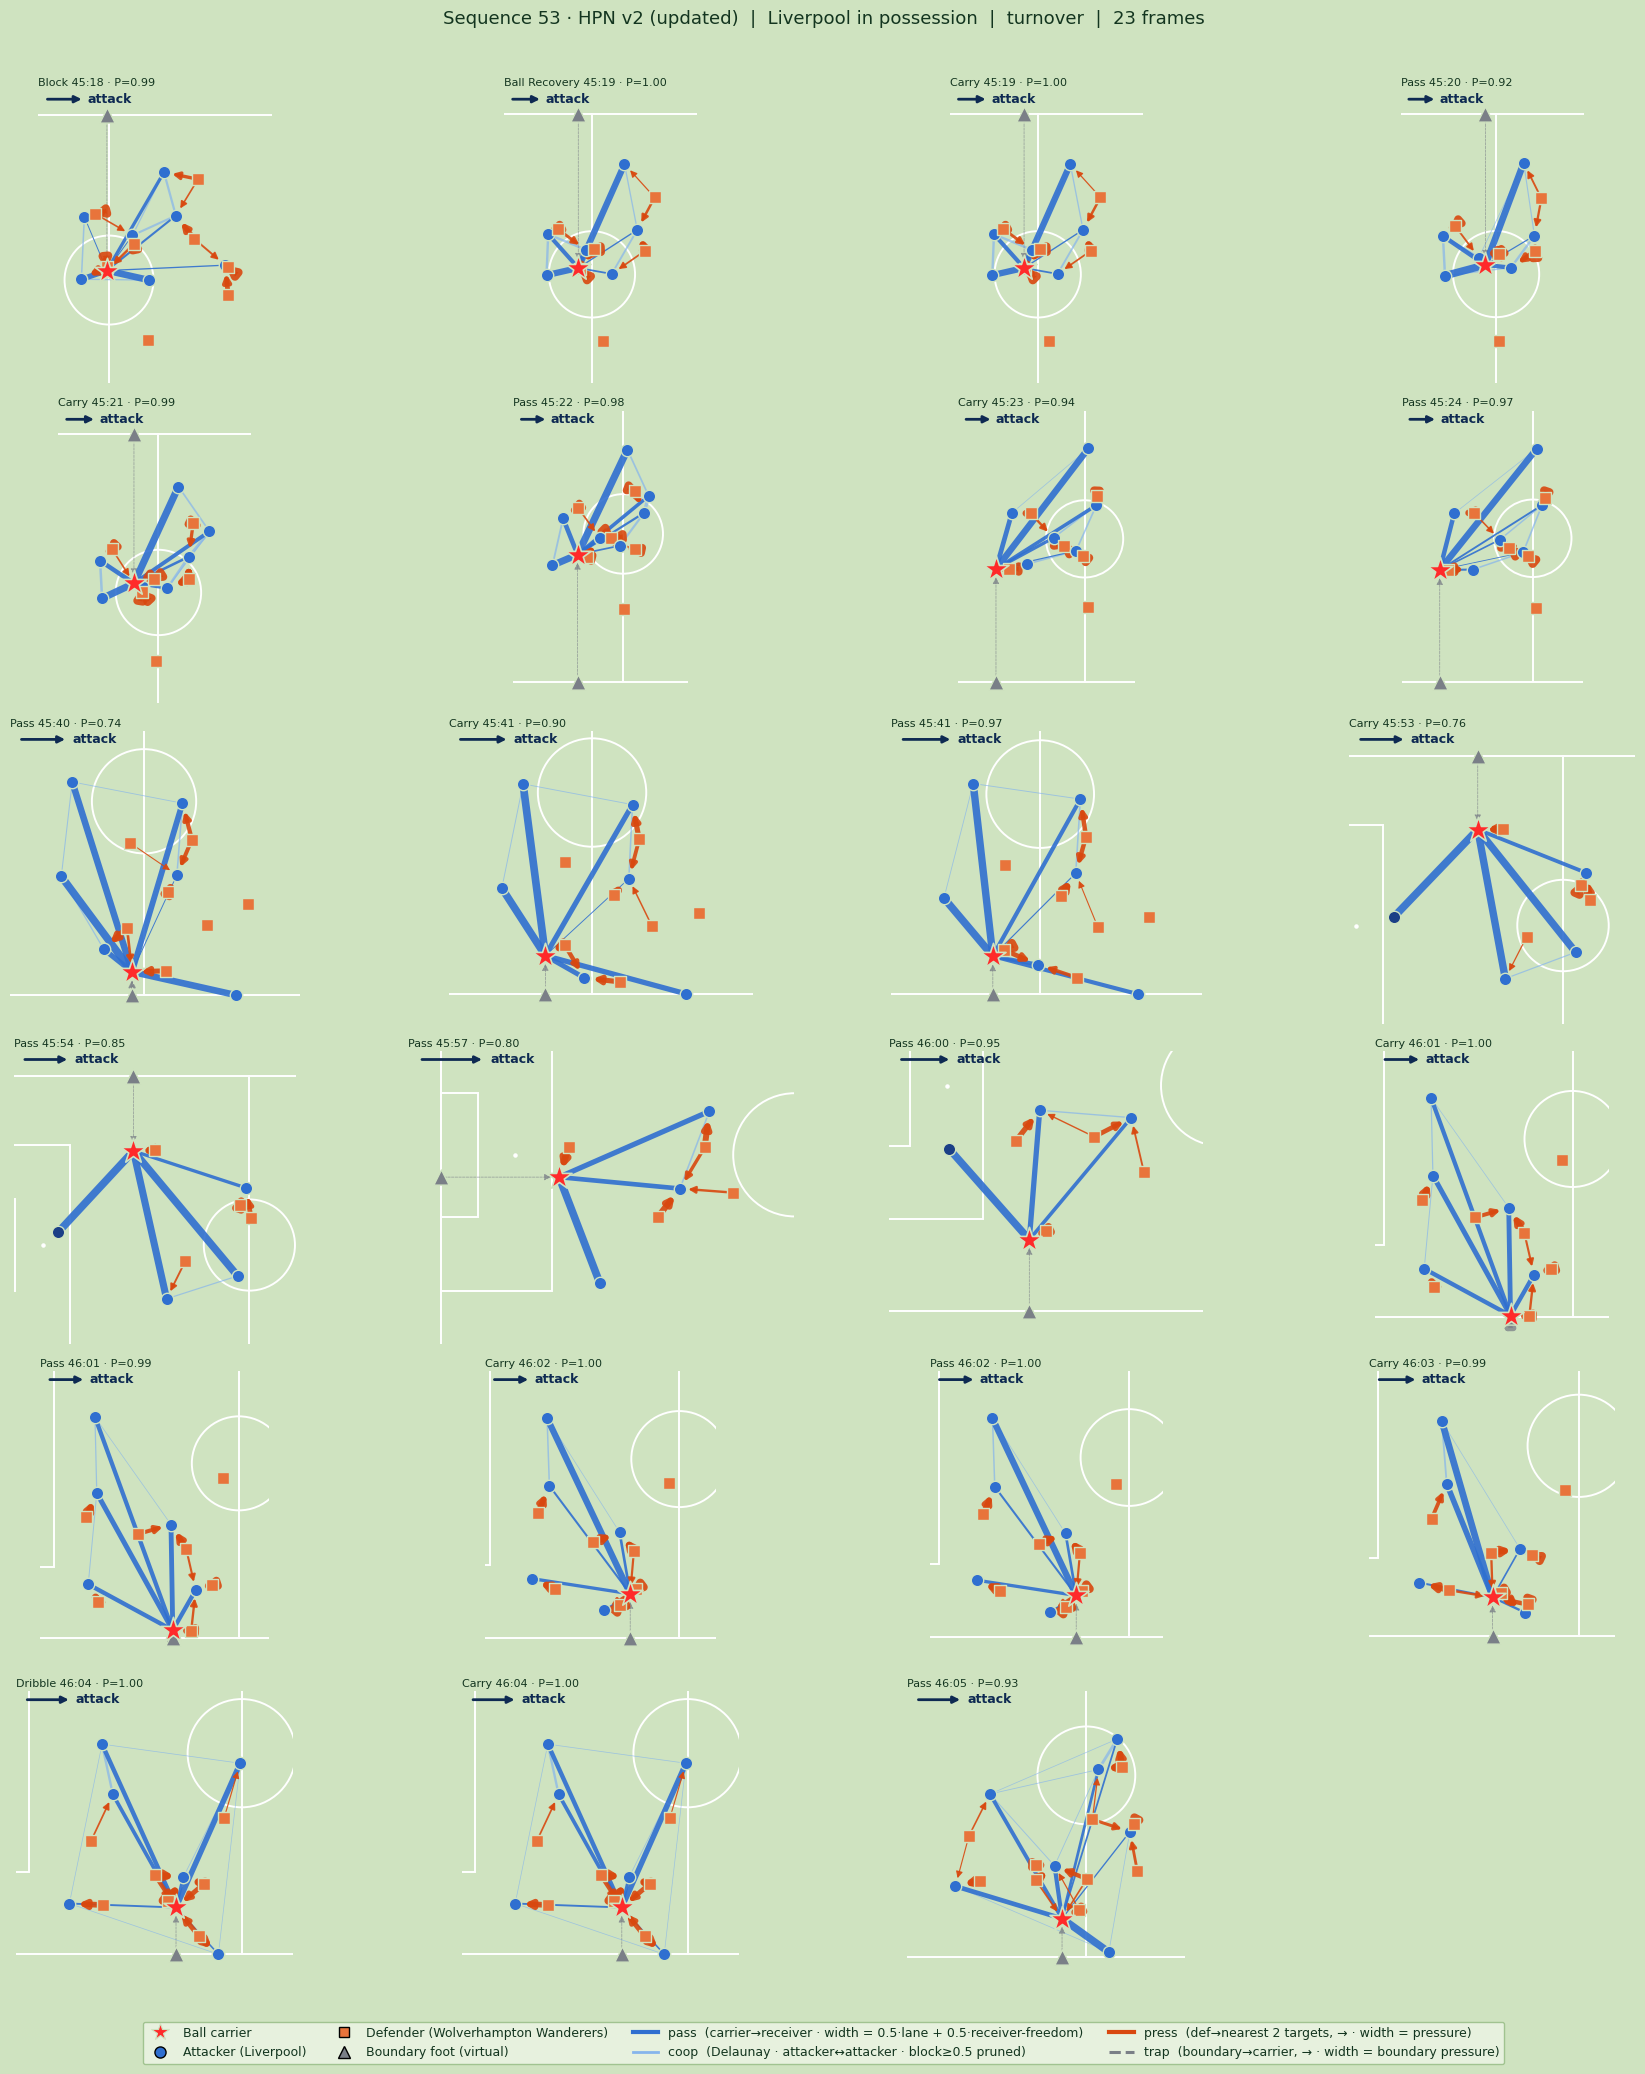

In [13]:
# Cell 11 — Sequence in the Cell-9 `plot_graph` schematic style (light pitch + shared legend)
# Updated HPN v2: coop = Delaunay (block>=0.5 pruned); pass width = 0.5*lane + 0.5*receiver-freedom.

def plot_sequence_schematic(seq_id, ncols=4):
    """Small-multiples of one sequence's high_press frames in the clean light-pitch
    schematic style of `plot_graph` (Cell 9), with one shared 8-item legend."""
    sub = seq_df[(seq_df.seq_id == seq_id) & (seq_df.frame_role == "high_press")]
    sub = sub[sub["id"].isin(frames)].sort_values("ev_pos")
    ids = sub["id"].tolist()
    if not ids:
        print(f"seq {seq_id}: no plottable frames"); return

    n = len(ids); nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.6 * ncols, 3.4 * nrows))
    fig.patch.set_facecolor(CLR_PITCH)                 # light schematic background (Cell 9 style)
    axes = np.atleast_1d(axes).flatten()

    meta_last = None
    for k, eid in enumerate(ids):
        nodes, edges, meta = event_graph(eid); meta_last = meta
        draw_graph(axes[k], nodes, edges, meta)
        axes[k].set_title(f"{meta['type']} {meta['minute']}:{meta['second']:02d} · P={meta['P_total']:.2f}",
                          fontsize=8, color=CLR_TXT, loc="left", pad=3)
    for k in range(n, len(axes)):
        axes[k].set_visible(False)

    m0 = seq_df[seq_df.seq_id == seq_id].iloc[0]
    fig.suptitle(f"Sequence {seq_id} · HPN v2 (updated)  |  {m0['possession_team']} in possession  "
                 f"|  {m0['end_reason']}  |  {n} frames",
                 color=CLR_TXT, fontsize=13, y=0.995)
    fig.legend(handles=_graph_legend(meta_last), loc="lower center",
               bbox_to_anchor=(0.5, -0.015), ncol=4, fontsize=9,
               framealpha=0.9, facecolor="#eaf3e2", edgecolor="#9bbf8a", labelcolor=CLR_TXT)
    plt.tight_layout(rect=[0, 0.02, 1, 0.985])
    plt.show()


# longest high-press sequence in this match (23 plottable frames)
plot_sequence_schematic(53)
